In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import math

In [44]:
def load_data(files, symbols):
    dfs = []
    for file, symbol in zip(files, symbols):
        df = pd.read_parquet(file)
        df['symbol'] = symbol  # Add the symbol column for each stock
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# List of files for multiple stocks and their symbols
files = ["data/2024_XIU.parquet", "data/2024_TD.parquet", "data/2024_BMO.parquet", "data/2024_BNS.parquet", "data/2024_RY.parquet"]
symbols = ["XIU", "TD", "BMO", "BNS", "RY"]  # Canadian market ETF and major Canadian banks

# Load data
df = load_data(files, symbols)

In [18]:
# Calculate daily returns
df['change_percent'] = df.groupby('symbol')['underlying_price'].pct_change() * 100

# Compute annualized volatility using daily returns by stock
volatility_by_stock = df.groupby('symbol')['change_percent'].std() * math.sqrt(250)  # 250 Canadian trading days
volatility_dict = volatility_by_stock.to_dict()

# Apply stock-specific volatility
df["sigma"] = df["symbol"].map(volatility_dict)

# Prepare dataframe with required parameters
df["T"] = df["dte"] / 365  # Time to maturity in years
df["r"] = 0.05  # Assuming a constant risk-free rate of 5%
df["S0"] = df["underlying_price"]
df["K"] = df["strike"]

# Filter for put options within 30-60 days to expiration
puts = df[df["option_type"] == "put"]
puts_monthly = puts[(puts["dte"] >= 30) & (puts["dte"] <= 60)]

In [19]:
# Define the binomial tree function
def binomial_tree_american_put(S0, K, r, sigma, T, M):
    dt = T / M
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)  # Risk-neutral probability
    discount = np.exp(-r * dt)

    # Stock prices at maturity
    stock_prices = np.asarray([S0 * (u ** j) * (d ** (M - j)) for j in range(M + 1)])
    option_values = np.maximum(K - stock_prices, 0)

    # Backward induction
    for t in range(M - 1, -1, -1):
        option_values = discount * (p * option_values[1:] + (1 - p) * option_values[:-1])
        stock_prices = stock_prices[:-1] / u  # Move back one step
        option_values = np.maximum(option_values, K - stock_prices)  # Check early exercise

    return option_values[0]

# Compute binomial tree prices for each stock
def binomial_tree_batched(S0, K, r, sigma, T, M=50, batch_size=1000):
    S0 = np.atleast_1d(S0)
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)

    L = len(S0)
    results = np.zeros(L)

    for i in range(0, L, batch_size):
        batch_end = min(i + batch_size, L)
        results[i:batch_end] = [
            binomial_tree_american_put(S0[j], K[j], r[j], sigma[j], T[j], M) for j in range(i, batch_end)
        ]

    return results

# Model Parameters
M = 50
batch_size = 1000

# Compute Binomial Tree Prices
puts_monthly["binomial_price"] = binomial_tree_batched(
    puts_monthly["S0"].values, puts_monthly["K"].values,
    puts_monthly["r"].values, puts_monthly["sigma"].values,
    puts_monthly["T"].values, M, batch_size
)

# Calculate moneyness (K/S ratio)
puts_monthly["moneyness"] = puts_monthly["K"] / puts_monthly["S0"]

# Calculate price difference and relative error
puts_monthly["price_diff"] = puts_monthly["binomial_price"] - puts_monthly["last_trade_price"]
puts_monthly["relative_error"] = puts_monthly["price_diff"] / puts_monthly["last_trade_price"]

# Calculate mispricing indicator (positive means potentially undervalued)
puts_monthly["mispricing"] = puts_monthly["binomial_price"] / puts_monthly["last_trade_price"] - 1

/var/folders/rg/2bldn1q14bq6fmvnqjxkn43r0000gn/T/ipykernel_85439/654737698.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts_monthly["binomial_price"] = binomial_tree_batched(
/var/folders/rg/2bldn1q14bq6fmvnqjxkn43r0000gn/T/ipykernel_85439/654737698.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts_monthly["moneyness"] = puts_monthly["K"] / puts_monthly["S0"]
/var/folders/rg/2bldn1q14bq6fmvnqjxkn43r0000gn/T/ipykernel_85439/654737698.py:55: SettingWithCopyWarning: 
A value is trying to be se

In [40]:
# Set style for all plots
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Create a scatter plot comparing model prices vs. market prices
def plot_model_vs_market():
    plt.figure(figsize=(10, 8))
    
    for symbol in symbols:
        symbol_data = puts_monthly[puts_monthly["symbol"] == symbol]
        plt.scatter(
            symbol_data["last_trade_price"],
            symbol_data["binomial_price"],
            alpha=0.7,
            label=symbol,
            s=50
        )
    
    # Add a diagonal line (perfect predictions)
    max_val = max(puts_monthly["last_trade_price"].max(), puts_monthly["binomial_price"].max())
    plt.plot([0, max_val], [0, max_val], 'k--', label='Perfect Match')
    
    plt.title("Binomial Model vs. Market Prices for Canadian Bank Put Options", fontsize=14)
    plt.xlabel("Market Price", fontsize=12)
    plt.ylabel("Binomial Model Price", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add text explaining the interpretation
    plt.text(
        0.02, 0.98,
        "Points above line: Model predicts higher prices (potentially undervalued)\n"
        "Points below line: Model predicts lower prices (potentially overvalued)",
        transform=plt.gca().transAxes,
        verticalalignment='top',
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    plt.tight_layout()
    return plt

# 2. Mispricing by moneyness
def plot_mispricing_by_moneyness():
    plt.figure(figsize=(10, 8))
    
    for symbol in symbols:
        symbol_data = puts_monthly[puts_monthly["symbol"] == symbol].copy()
        
        # Clean mispricing: drop inf/nan and cap extreme values
        symbol_data["mispricing"] = symbol_data["mispricing"].replace([np.inf, -np.inf], np.nan)
        symbol_data = symbol_data.dropna(subset=["mispricing", "moneyness"])
        symbol_data = symbol_data[symbol_data["mispricing"].abs() < 2]  # cap at 200%
        
        symbol_data = symbol_data.sort_values("moneyness")
        
        plt.scatter(
            symbol_data["moneyness"],
            symbol_data["mispricing"] * 100,
            alpha=0.7,
            label=symbol,
            s=50
        )

    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.axhline(y=10, color='g', linestyle='--', alpha=0.5, label='Buy Threshold (+10%)')
    plt.axhline(y=-10, color='r', linestyle='--', alpha=0.5, label='Sell Threshold (-10%)')

    plt.title("Option Mispricing by Moneyness (Capped ±200%)", fontsize=14)
    plt.xlabel("Moneyness (Strike / Spot)", fontsize=12)
    plt.ylabel("Mispricing (%)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# 3. avg mispricing bar
def plot_avg_mispricing_bar():
    summary = puts_monthly.copy()
    summary["mispricing"] = summary["mispricing"].replace([np.inf, -np.inf], np.nan)
    summary = summary.dropna(subset=["mispricing"])
    summary = summary[summary["mispricing"].abs() < 2]  # cap at 200%

    avg_mispricing = summary.groupby("symbol")["mispricing"].mean().sort_values()

    plt.figure(figsize=(8, 6))
    avg_mispricing.plot(kind='barh', color='dodgerblue')
    plt.axvline(0, linestyle='--', color='black', alpha=0.7)
    plt.axvline(0.1, linestyle='--', color='green', alpha=0.6, label="+10% Buy Threshold")
    plt.axvline(-0.1, linestyle='--', color='red', alpha=0.6, label="-10% Sell Threshold")
    plt.xlabel("Average Mispricing (%)")
    plt.title("Average Mispricing by Stock (Capped ±200%)", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 4. Visualize top trading opportunities
import seaborn as sns

def plot_mispricing_boxplot():
    plt.figure(figsize=(10, 6))
    clean = puts_monthly.copy()
    clean["mispricing"] = clean["mispricing"].replace([np.inf, -np.inf], np.nan)
    clean = clean.dropna(subset=["mispricing"])
    clean = clean[clean["mispricing"].abs() < 2]  # cap at 200%
    
    sns.boxplot(data=clean, x="symbol", y="mispricing", color="skyblue")
    plt.axhline(0, linestyle='--', color='black', alpha=0.7)
    plt.axhline(0.1, linestyle='--', color='green', alpha=0.6, label="+10% Buy Threshold")
    plt.axhline(-0.1, linestyle='--', color='red', alpha=0.6, label="-10% Sell Threshold")
    
    plt.title("Mispricing Distribution by Stock (Capped ±200%)", fontsize=14)
    plt.ylabel("Mispricing (%)", fontsize=12)
    plt.xlabel("Stock Symbol", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()
       



In [41]:
# 5. Generate summary statistics
def generate_performance_report():
    """Generate a summary report of the model performance and trading opportunities"""
    # Calculate statistics for each stock
    stats = []
    
    for symbol in symbols:
        symbol_data = puts_monthly[puts_monthly["symbol"] == symbol]
        
        # Model accuracy metrics
        mean_abs_error = symbol_data["price_diff"].abs().mean()
        mean_rel_error = symbol_data["relative_error"].abs().mean()
        
        # Trading opportunities
        buy_count = sum(symbol_data["mispricing"] > 0.1)
        sell_count = sum(symbol_data["mispricing"] < -0.1)
        
        # Volatility
        volatility = volatility_dict[symbol]
        
        stats.append({
            "Symbol": symbol,
            "Volatility": volatility,
            "Mean Abs Error": mean_abs_error,
            "Mean Rel Error": mean_rel_error * 100,  # as percentage
            "Buy Opportunities": buy_count,
            "Sell Opportunities": sell_count,
            "Total Options": len(symbol_data)
        })
    
    return pd.DataFrame(stats)


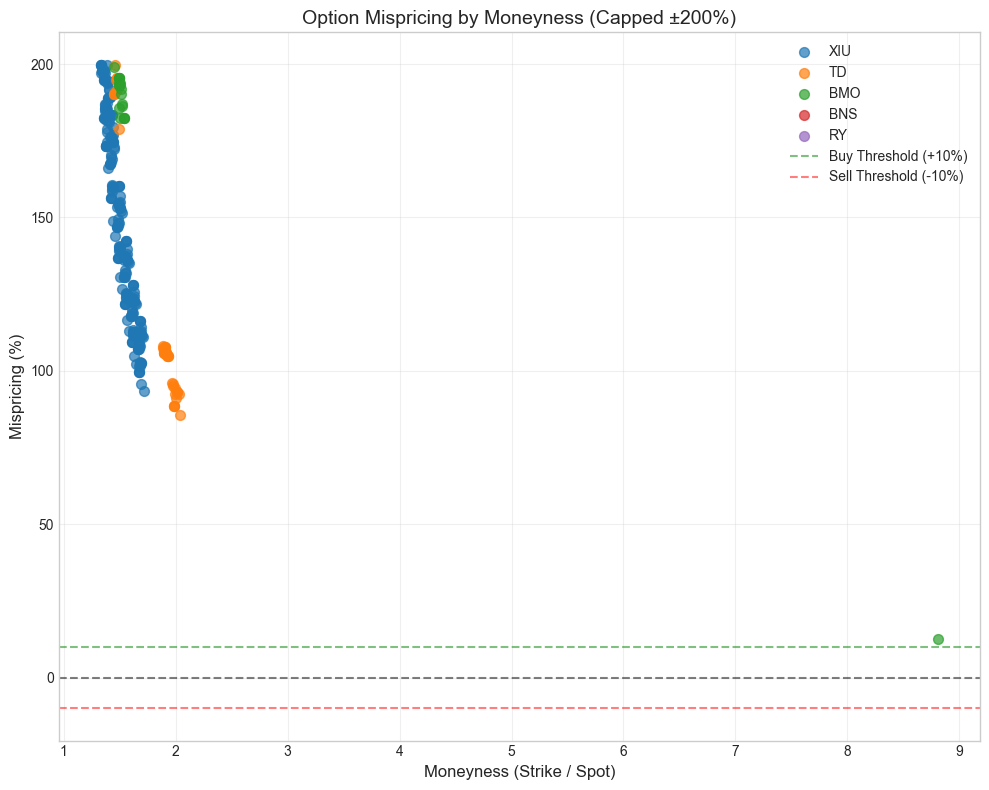

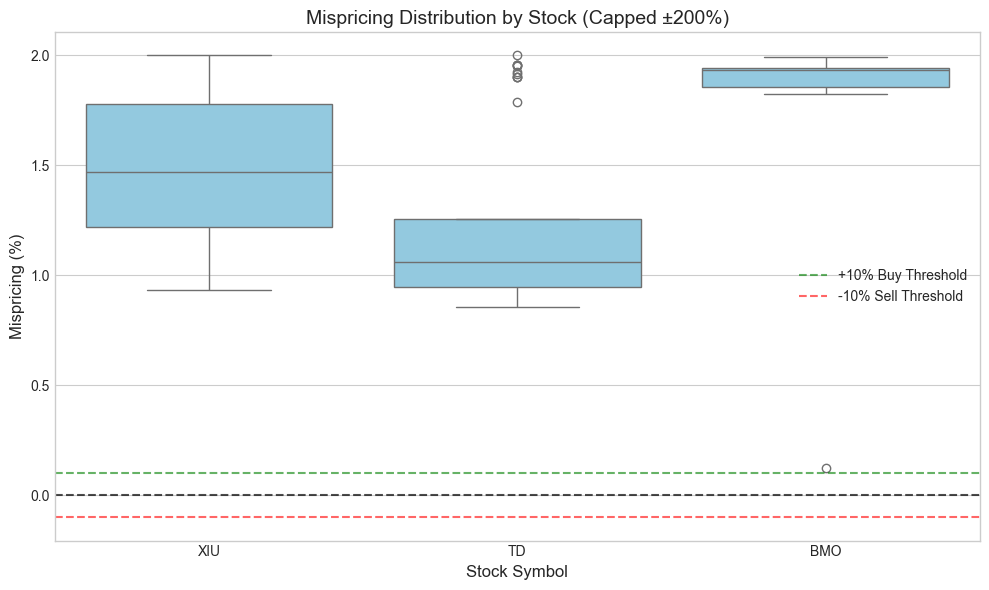

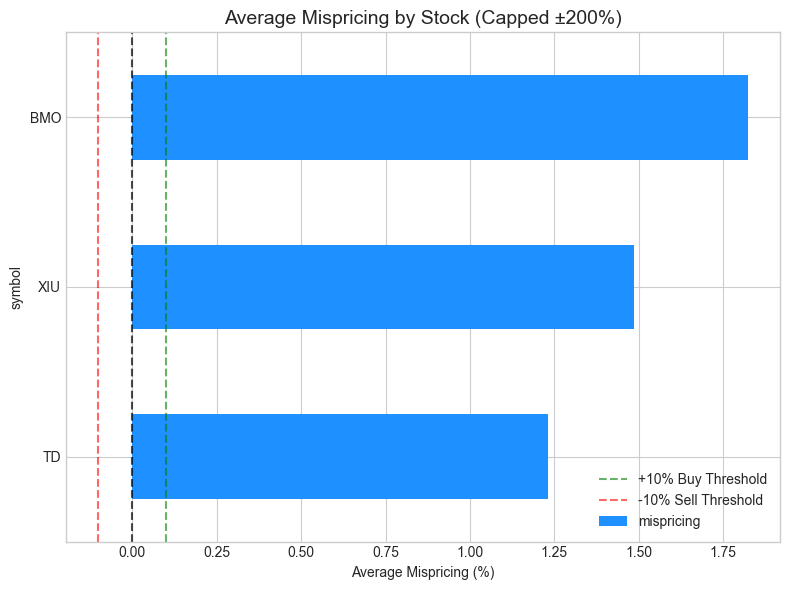

AttributeError: 'NoneType' object has no attribute 'show'

In [42]:
import matplotlib.pyplot as plt
import IPython.display as display

# Generate plots
mispricing_plot = plot_mispricing_by_moneyness()
mispricing_box = plot_mispricing_boxplot()
mispricing_bar = plot_avg_mispricing_bar()

# Show the plots directly
mispricing_plot.show()
mispricing_box.show()
mispricing_bar.show()



--- Backtest Summary by Stock ---
        avg_pnl  total_pnl  num_trades  num_buys  num_sells
symbol                                                     
BMO        5.21   89775.65       17245     17245          0
BNS        1.95   31315.27       16043     16043          0
RY         3.94   68756.59       17468     17468          0
TD         3.45   52176.33       15118     15118          0
XIU        0.31    9609.08       31256     31256          0


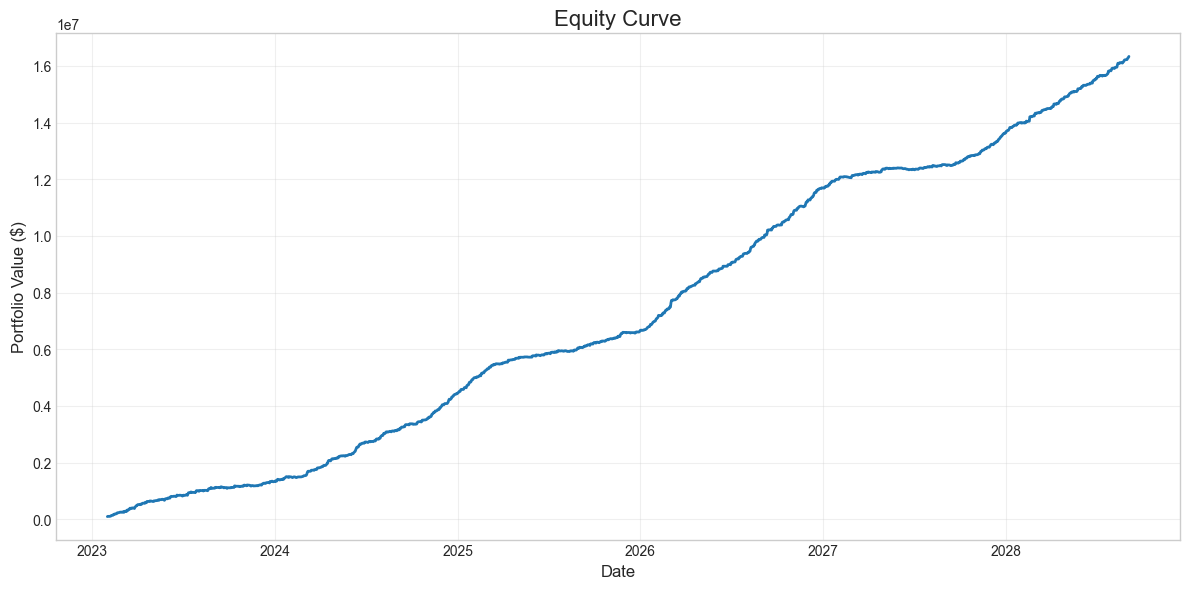

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# -------------------------------
# 1. Simulate terminal price using GBM
# -------------------------------
np.random.seed(42)

def simulate_terminal_price(S0, sigma, r, T):
    return S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * np.random.randn())

puts_monthly = puts_monthly.copy()

puts_monthly["S_T"] = puts_monthly.apply(
    lambda row: simulate_terminal_price(row["S0"], row["sigma"], row["r"], row["T"]),
    axis=1
)

puts_monthly["payoff"] = np.maximum(puts_monthly["K"] - puts_monthly["S_T"], 0)

# -------------------------------
# 2. Define trading signals & PnL
# -------------------------------
buy_signals = puts_monthly[puts_monthly["mispricing"] > 0.1].copy()
buy_signals["pnl"] = buy_signals["payoff"] - buy_signals["last_trade_price"]
buy_signals["signal"] = "Buy"

sell_signals = puts_monthly[puts_monthly["mispricing"] < -0.1].copy()
sell_signals["pnl"] = sell_signals["last_trade_price"] - sell_signals["payoff"]
sell_signals["signal"] = "Sell"

# Combine trades
trades = pd.concat([buy_signals, sell_signals], ignore_index=True)

# -------------------------------
# 3. Clean and validate DTE
# -------------------------------
trades["dte"] = pd.to_numeric(trades["dte"], errors="coerce")
trades = trades.dropna(subset=["dte"])
trades = trades[(trades["dte"] >= 1) & (trades["dte"] <= 365)]
trades["dte"] = trades["dte"].astype(int)

# -------------------------------
# 4. Summary stats
# -------------------------------
summary = trades.groupby("symbol").agg(
    avg_pnl=("pnl", "mean"),
    total_pnl=("pnl", "sum"),
    num_trades=("pnl", "count"),
    num_buys=("signal", lambda x: (x == "Buy").sum())
)
summary["num_sells"] = summary["num_trades"] - summary["num_buys"]

print("\n--- Backtest Summary by Stock ---")
print(summary.round(2))

# -------------------------------
# 5. Equity Curve Construction
# -------------------------------
initial_capital = 100000
trade_size = 0.05  # Fixed amount per trade
trades = trades.reset_index(drop=True)

# Generate safe timeline (10 trades per day)
start_date = pd.Timestamp("2023-01-01")
trades["trade_date"] = [start_date + pd.Timedelta(days=i // 10) for i in range(len(trades))]
trades["exit_date"] = trades["trade_date"] + pd.to_timedelta(trades["dte"], unit='D')

# Scale PnL by trade size
trades["scaled_pnl"] = trades["pnl"] * (trade_size / trades["last_trade_price"])

# Sort by exit date
trades = trades.sort_values("exit_date")

# -------------------------------
# 6. Create equity curve
# -------------------------------
equity = pd.DataFrame()
equity["date"] = trades["exit_date"]
equity["pnl"] = trades["scaled_pnl"]
equity = equity.groupby("date")["pnl"].sum().cumsum().reset_index()
equity["portfolio_value"] = initial_capital + equity["pnl"]

# Fill in missing dates for smooth curve
all_dates = pd.date_range(start=equity["date"].min(), end=equity["date"].max())
equity_full = pd.DataFrame({"date": all_dates})
equity_full = equity_full.merge(equity[["date", "portfolio_value"]], on="date", how="left")
equity_full["portfolio_value"] = equity_full["portfolio_value"].ffill().fillna(initial_capital)

# -------------------------------
# 7. Plot equity curve
# -------------------------------
plt.figure(figsize=(12, 6))
plt.plot(equity_full["date"], equity_full["portfolio_value"], linewidth=2)
plt.title("Equity Curve", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
